In [1]:
import pandas as pd

df = pd.read_csv('immo_data.csv', engine='python', on_bad_lines='skip')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nbaseRent stats:")
print(df['baseRent'].describe())

Shape: (268850, 49)

Columns: ['regio1', 'serviceCharge', 'heatingType', 'telekomTvOffer', 'telekomHybridUploadSpeed', 'newlyConst', 'balcony', 'picturecount', 'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed', 'scoutId', 'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln', 'cellar', 'yearConstructedRange', 'baseRent', 'houseNumber', 'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed', 'street', 'streetPlain', 'lift', 'baseRentRange', 'typeOfFlat', 'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors', 'noRoomsRange', 'garden', 'livingSpaceRange', 'regio2', 'regio3', 'description', 'facilities', 'heatingCosts', 'energyEfficiencyClass', 'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice', 'date']

baseRent stats:
count    2.688500e+05
mean     6.941294e+02
std      1.953602e+04
min      0.000000e+00
25%      3.380000e+02
50%      4.900000e+02
75%      7.990000e+02
max      9.999999e+06
Name: baseRent, dtype: float64


In [2]:
# keep only useful columns
keep = ['baseRent', 'livingSpace', 'noRooms', 'yearConstructed', 'condition',
        'regio1', 'regio2', 'newlyConst', 'balcony', 'hasKitchen', 'cellar',
        'lift', 'garden', 'typeOfFlat', 'floor']
data = df[keep].copy()

# --- clean the target (baseRent) ---
# drop junk: rent must be sensible. Keep 100 to 10,000 €/month
before = len(data)
data = data[(data['baseRent'] >= 100) & (data['baseRent'] <= 10000)]
print(f"Dropped {before - len(data)} rows with junk rent")

# clean livingSpace too (no 0 or absurd sizes)
data = data[(data['livingSpace'] >= 10) & (data['livingSpace'] <= 1000)]

# clean year (no future or ancient typos)
data = data[(data['yearConstructed'] >= 1850) & (data['yearConstructed'] <= 2025) | data['yearConstructed'].isna()]

print("Shape after cleaning:", data.shape)
print("\nbaseRent now:")
print(data['baseRent'].describe().round(0))
print("\nMissing % per column:")
print((data.isna().mean()*100).sort_values(ascending=False).round(1))

Dropped 241 rows with junk rent
Shape after cleaning: (267184, 15)

baseRent now:
count    267184.0
mean        647.0
std         493.0
min         100.0
25%         338.0
50%         490.0
75%         799.0
max       10000.0
Name: baseRent, dtype: float64

Missing % per column:
condition          25.5
yearConstructed    21.3
floor              19.0
typeOfFlat         13.6
baseRent            0.0
livingSpace         0.0
noRooms             0.0
regio1              0.0
regio2              0.0
newlyConst          0.0
balcony             0.0
hasKitchen          0.0
cellar              0.0
lift                0.0
garden              0.0
dtype: float64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
import numpy as np

d = data.copy()

# encode text columns to numbers
cat_cols = ['regio1', 'regio2', 'condition', 'typeOfFlat']
for c in cat_cols:
    d[c] = LabelEncoder().fit_transform(d[c].astype(str))

# bool columns to int
for c in ['newlyConst','balcony','hasKitchen','cellar','lift','garden']:
    d[c] = d[c].astype(int)

X = d.drop(columns=['baseRent'])
y = d['baseRent']

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

def report(name, pred):
    mae = mean_absolute_error(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    r2 = r2_score(yte, pred)
    print(f"{name}: MAE €{mae:.0f} | RMSE €{rmse:.0f} | R² {r2:.3f}")

# --- baseline: Linear Regression (needs imputed values) ---
imp = SimpleImputer(strategy='median')
Xtr_i = imp.fit_transform(Xtr)
Xte_i = imp.transform(Xte)
lr = LinearRegression().fit(Xtr_i, ytr)
report("Linear Regression", lr.predict(Xte_i))

# --- main: LightGBM (handles missing values itself) ---
lgb = LGBMRegressor(n_estimators=600, learning_rate=0.03,
                    num_leaves=40, random_state=42)
lgb.fit(Xtr, ytr)
report("LightGBM", lgb.predict(Xte))


Linear Regression: MAE €175 | RMSE €287 | R² 0.650
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004685 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 788
[LightGBM] [Info] Number of data points in the train set: 213747, number of used features: 14
[LightGBM] [Info] Start training from score 647.349844
LightGBM: MAE €100 | RMSE €179 | R² 0.864


            feature  importance
5            regio2        6694
0       livingSpace        4431
4            regio1        2877
2   yearConstructed        2808
3         condition        1283
13            floor        1153
1           noRooms        1094
12       typeOfFlat        1008
8        hasKitchen         713
10             lift         518
9            cellar         473
7           balcony         213
11           garden          85
6        newlyConst          50


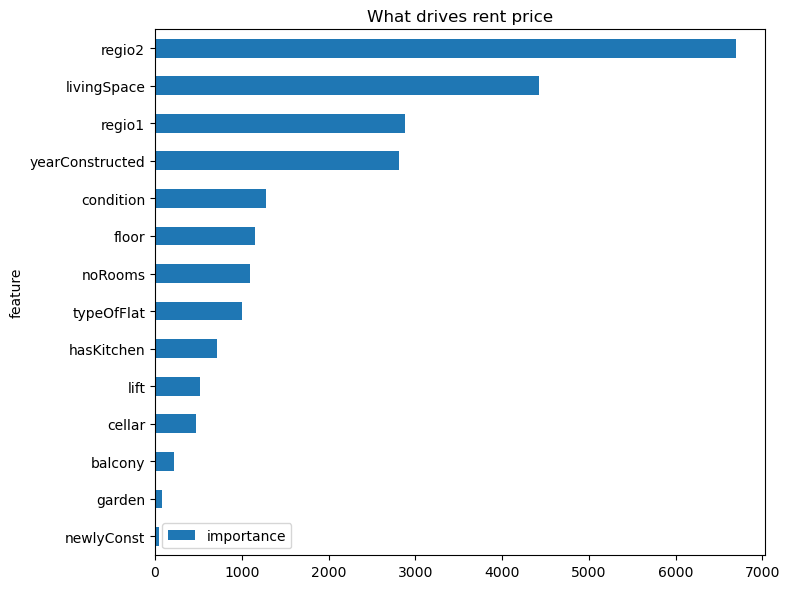

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb.feature_importances_
}).sort_values('importance', ascending=False)

print(imp_df)

imp_df.plot(kind='barh', x='feature', y='importance', figsize=(8,6),
            title='What drives rent price')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [5]:
import joblib

# retrain on all data for the final model
lgb_final = LGBMRegressor(n_estimators=600, learning_rate=0.03,
                          num_leaves=40, random_state=42)
lgb_final.fit(X, y)

joblib.dump(lgb_final, 'rent_model.pkl')
joblib.dump(list(X.columns), 'rent_columns.pkl')

# save the encoders so the app can convert city/state text to numbers
encoders = {}
for c in cat_cols:
    le = LabelEncoder().fit(data[c].astype(str))
    encoders[c] = list(le.classes_)
joblib.dump(encoders, 'rent_encoders.pkl')



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 786
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 14
[LightGBM] [Info] Start training from score 646.568119


['rent_encoders.pkl']

In [6]:
import os
print(os.getcwd())

c:\Users\Acer\Desktop\Data Science AI and Digital Buisness\Term 5\Business Project in Big Data and AI\New folder
